In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn


def ebno_to_noise_std(
    ebno_db: float, bits_per_symbol: int, num_complex_dims: int = 1
) -> float:
  ebno_linear = 10.0 ** (ebno_db / 10.0)
  code_rate = bits_per_symbol / (2.0 * num_complex_dims)
  noise_variance = 1.0 / (2.0 * code_rate * ebno_linear)
  return np.sqrt(noise_variance)


class AWGNChannel(nn.Module):

  def __init__(self):
    super(AWGNChannel, self).__init__()

  def forward(self, x: torch.Tensor, noise_std: float) -> torch.Tensor:
    noise = torch.randn_like(x) * noise_std
    return x + noise


class RayleighChannel(nn.Module):

  def __init__(self):
    super(RayleighChannel, self).__init__()

  def forward(self, x: torch.Tensor, noise_std: float, return_csi: bool = False):
    batch_size = x.shape[0]
    device = x.device
    h_r = torch.randn(batch_size, 1, device=device) * np.sqrt(0.5)
    h_i = torch.randn(batch_size, 1, device=device) * np.sqrt(0.5)

    x_i = x[:, 0:1]
    x_q = x[:, 1:2]

    y_i = h_r * x_i - h_i * x_q
    y_q = h_i * x_i + h_r * x_q

    y_faded = torch.cat([y_i, y_q], dim=1)
    noise = torch.randn_like(y_faded) * noise_std
    y_received = y_faded + noise

    if return_csi:
      h_matrix = torch.cat([h_r, h_i], dim=1)
      return y_received, h_matrix
    return y_received


# Simulación Monte Carlo QPSK
np.random.seed(42)
torch.manual_seed(42)

num_samples = 2000
qpsk_symbols = torch.tensor(
    [[1.0, 1.0], [1.0, -1.0], [-1.0, 1.0], [-1.0, -1.0]]
) / np.sqrt(2)
indices = torch.randint(0, 4, (num_samples,))
x_test = qpsk_symbols[indices]

noise_std = ebno_to_noise_std(ebno_db=10.0, bits_per_symbol=2)

awgn = AWGNChannel()
rayleigh = RayleighChannel()

y_awgn = awgn(x_test, noise_std).numpy()
y_rayleigh = rayleigh(x_test, noise_std).numpy()
x_np = x_test.numpy()

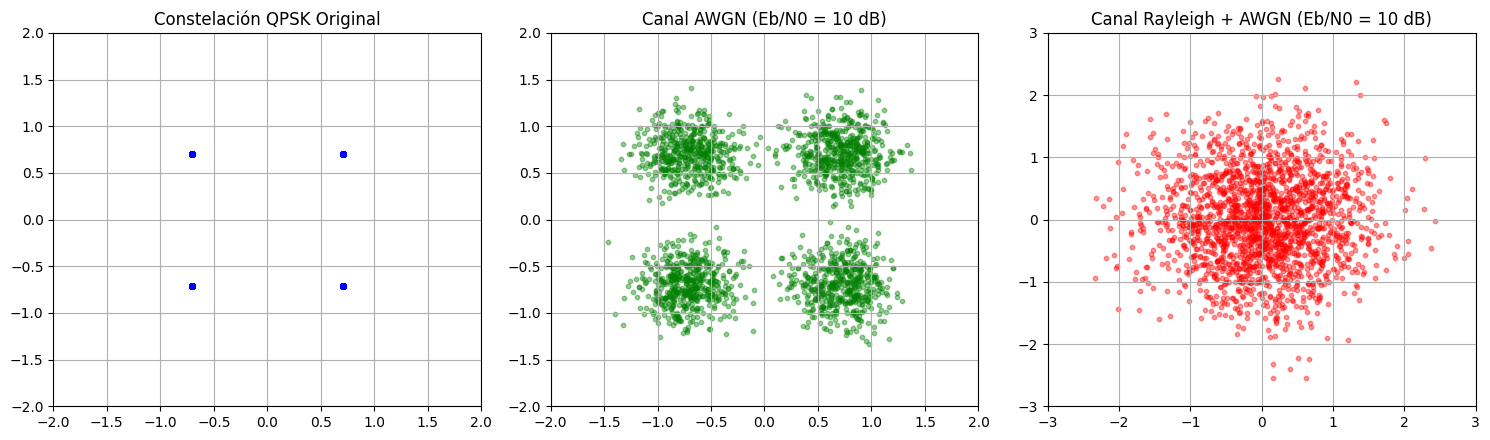

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(x_np[:, 0], x_np[:, 1], color="blue", alpha=0.6, s=15)
axes[0].set_title("Constelación QPSK Original")
axes[0].set_xlim([-2, 2])
axes[0].set_ylim([-2, 2])
axes[0].grid(True)

axes[1].scatter(y_awgn[:, 0], y_awgn[:, 1], color="green", alpha=0.4, s=10)
axes[1].set_title("Canal AWGN (Eb/N0 = 10 dB)")
axes[1].set_xlim([-2, 2])
axes[1].set_ylim([-2, 2])
axes[1].grid(True)

axes[2].scatter(y_rayleigh[:, 0], y_rayleigh[:, 1], color="red", alpha=0.4, s=10)
axes[2].set_title("Canal Rayleigh + AWGN (Eb/N0 = 10 dB)")
axes[2].set_xlim([-3, 3])
axes[2].set_ylim([-3, 3])
axes[2].grid(True)

plt.tight_layout()
plt.show()